In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from scipy.stats import pearsonr

In [6]:
news_df = pd.read_csv("../data/raw/raw_analyst_ratings.csv")
stock_df = pd.read_csv("../data/raw/AAPL.csv")

In [9]:
news_df = news_df[news_df['stock'] == 'AAPL']

In [10]:
news_df.head()
stock_df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [16]:
news_df['date'] = pd.to_datetime(
    news_df['date'],
    format='mixed',
    utc=True
)

stock_df['Date'] = pd.to_datetime(stock_df['Date'])

In [17]:
news_df['news_date'] = news_df['date'].dt.date
stock_df['trading_date'] = stock_df['Date'].dt.date

In [18]:
trading_days = pd.Series(stock_df['Date'].dt.date)

def get_next_trading_day(news_date):
    future_days = trading_days[trading_days >= news_date]
    return future_days.min()

news_df['aligned_date'] = news_df['news_date'].apply(get_next_trading_day)

In [19]:
analyzer = SentimentIntensityAnalyzer()

In [20]:
news_df['sentiment_score'] = news_df['headline'].apply(
    lambda x: analyzer.polarity_scores(str(x))['compound']
)

In [21]:
daily_sentiment = (
    news_df.groupby(['stock', 'aligned_date'])['sentiment_score']
    .mean()
    .reset_index()
)

In [23]:
stock_df['daily_return'] = (
    stock_df['Close'].pct_change() * 100
)

In [24]:
returns_df = stock_df[['Date', 'daily_return']].copy()
returns_df['aligned_date'] = returns_df['Date'].dt.date

In [25]:
merged_df = pd.merge(
    daily_sentiment,
    returns_df,
    on='aligned_date',
    how='inner'
)

In [26]:
corr, p_value = pearsonr(
    merged_df['sentiment_score'],
    merged_df['daily_return']
)

print("Correlation:", corr)
print("P-value:", p_value)

Correlation: 0.16441217194906854
P-value: 0.20545165902435536


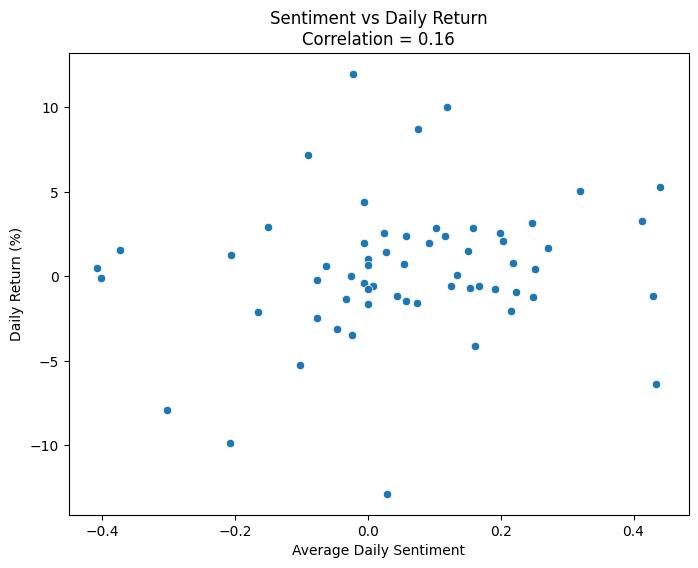

In [27]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=merged_df,
    x='sentiment_score',
    y='daily_return'
)

plt.title(f'Sentiment vs Daily Return\nCorrelation = {corr:.2f}')
plt.xlabel("Average Daily Sentiment")
plt.ylabel("Daily Return (%)")

plt.show()

In [28]:
def classify_sentiment(score):
    if score > 0.05:
        return 'Positive'
    elif score < -0.05:
        return 'Negative'
    else:
        return 'Neutral'

merged_df['sentiment_category'] = merged_df['sentiment_score'].apply(
    classify_sentiment
)

In [29]:
category_returns = (
    merged_df.groupby('sentiment_category')['daily_return']
    .mean()
    .reset_index()
)

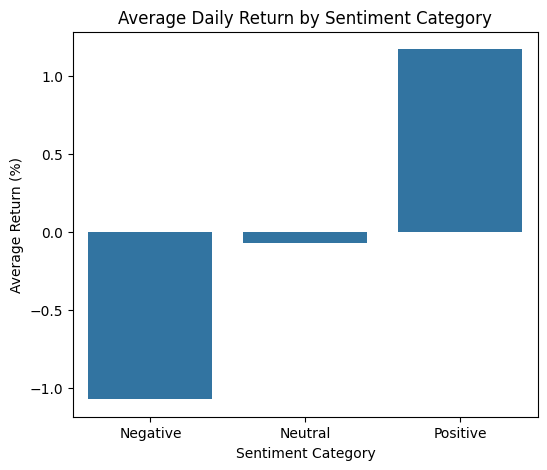

In [30]:
plt.figure(figsize=(6,5))

sns.barplot(
    data=category_returns,
    x='sentiment_category',
    y='daily_return'
)

plt.title("Average Daily Return by Sentiment Category")
plt.xlabel("Sentiment Category")
plt.ylabel("Average Return (%)")

plt.show()

A correlation value of 0.16 was obtained between the news sentiment and daily stock returns, implying a weak positive correlation between financial news sentiment and the performance of stocks. Therefore, it is safe to conclude that on days when there were more positive news headlines, there were higher daily stock returns, but on the contrary, during days when the sentiments were negative, daily stock returns were lower. There is also an indication of a weak correlation between the two variables since there exists a mild upward trend with scattered data points in the scatter plot.

From the sentiment category analysis, days categorized as having positive sentiment had the highest average daily stock returns, whereas negative sentiment had average losses. The neutral sentiment days were near zero average daily stock returns. However, the connection between stock prices and sentiment is still weak due to other elements affecting stock prices. Stock prices are determined by various factors, including earnings announcement, economic news, expectations, and unforeseen occurrences. Moreover, this study only considers the contemporaneous correlation and ignores any delayed effect.